# Stage 4 — Anomaly detection

## Why bother, given a working classifier?

Because the classifier can only recognise the four fault modes it was trained
on. A real plant also suffers faults nobody labelled: a new tool supplier with
different wear behaviour, a degrading coolant pump, a miscalibrated sensor, a
change in material batch. For those there are no positive examples to learn
from, by definition.

An **Isolation Forest** fitted on healthy operation only gives a second,
label-free opinion: *this machine is operating unlike anything in its own normal
history.* That is a different question from *this machine matches a known
failure pattern*, and it is the reason both stages exist.

Fitting on healthy rows only is what makes this a genuine novelty detector
rather than a repackaged classifier. Labels are used strictly to **evaluate** it
afterwards — never to fit it.


In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg, data, features, eda, models, evaluate, anomaly, explain, viz
viz.apply_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)


In [2]:
df = features.add_physics_features(data.add_targets(data.load_raw()))
train_df, test_df = data.stratified_split(df)
X_train = features.X_frame(train_df); y_train = train_df["y_failure"].to_numpy()
X_test  = features.X_frame(test_df);  y_test  = test_df["y_failure"].to_numpy()

detector = anomaly.build_anomaly_detector()
anomaly.fit_on_healthy(detector, X_train, y_train)
print(f"fitted on {int((y_train == 0).sum()):,} healthy training rows")
print(f"withheld  {int(y_train.sum())} failed training rows — never seen by the detector")

fitted on 7,729 healthy training rows
withheld  271 failed training rows — never seen by the detector


In [3]:
scores_test = anomaly.anomaly_scores(detector, X_test)
print(f"scored {len(scores_test):,} held-out machines")
print(f"score range: {scores_test.min():+.3f} to {scores_test.max():+.3f}")
print("(higher = more unusual)")

scored 2,000 held-out machines
score range: +0.396 to +0.647
(higher = more unusual)


## Does unusualness actually track failure?


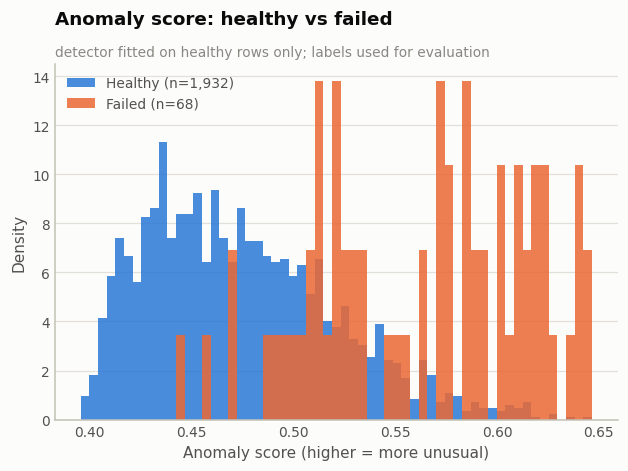

In [4]:
ax = anomaly.plot_score_distribution(scores_test, y_test)
plt.show()

In [5]:
anom_eval = anomaly.evaluate_detector(scores_test, y_test)
print(f"PR-AUC  {anom_eval['pr_auc']:.3f}")
print(f"ROC-AUC {anom_eval['roc_auc']:.3f}")
print(f"(base failure rate in this sample: {anom_eval['base_failure_rate']:.2%})")

PR-AUC  0.364
ROC-AUC 0.892
(base failure rate in this sample: 3.40%)


The distributions overlap substantially, and they should. Most failures in this
dataset happen at operating points that are *individually* unremarkable — normal
torque, normal speed, ordinary tool wear — and only become dangerous in
combination. An unsupervised detector with no access to labels cannot know which
combinations matter.

So the honest read is: the anomaly detector is clearly informative but clearly
weaker than the supervised classifier. That is the expected result, and it is
why it is positioned as a safety net rather than the primary alarm.

## The operational framing that actually matters

PR-AUC is abstract. The question a maintenance planner asks is concrete: *if my
crew can only inspect 1% of the fleet today, does this ranking help?*


In [6]:
pd.DataFrame(anom_eval["top_k"]).assign(
    recall=lambda d: (100 * d["recall"]).round(1),
    precision=lambda d: (100 * d["precision"]).round(1),
    lift_vs_random=lambda d: d["lift_vs_random"].round(1),
).rename(columns={"recall": "recall_%", "precision": "precision_%"})

,fraction_inspected,machines_inspected,failures_found,recall_%,precision_%,lift_vs_random
0,0.010,20,13,19.1,65.0,19.1
1,0.034,68,29,42.6,42.6,12.5
2,0.050,100,37,54.4,37.0,10.9
3,0.100,200,42,61.8,21.0,6.2


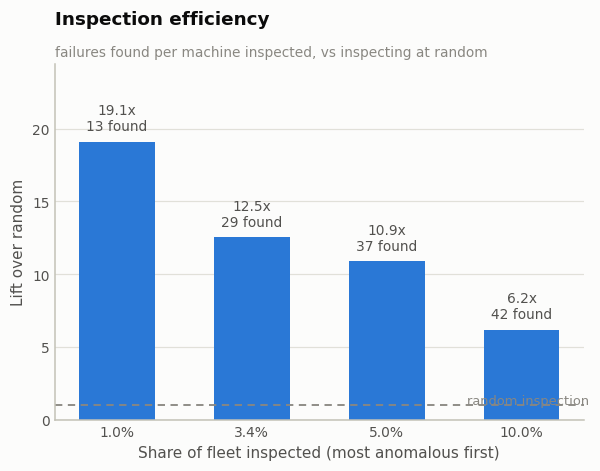

In [7]:
ax = anomaly.plot_top_k_lift(anom_eval)
plt.show()

This is the result worth quoting. Inspecting the **1% most anomalous** machines
finds failures at roughly **19× the rate of random inspection** — with a model
that was never shown a single failure label.

## How the two stages complement each other

The interesting question is whether the anomaly detector catches anything the
classifier misses. If the two agree perfectly, the second one is redundant.


In [8]:
zoo = models.build_models(pos_weight=models.positive_weight(y_train))
clf = zoo["Random forest"]
clf.fit(X_train, y_train)
p_test = clf.predict_proba(X_test)[:, 1]

# Threshold re-derived out-of-fold, consistent with Stage 3.
oof, _ = models.cross_val_oof({"Random forest": zoo["Random forest"]}, X_train, y_train)
threshold = evaluate.tune_threshold_by_cost(y_train, oof["Random forest"])["threshold"]

clf_alarm  = p_test >= threshold
anom_alarm = scores_test >= np.percentile(scores_test, 100 - 3.4)

overlap = pd.crosstab(
    pd.Series(clf_alarm,  name="classifier alarm"),
    pd.Series(anom_alarm, name="anomaly alarm"),
)
print(overlap.to_string())
print()
missed_by_clf = (~clf_alarm) & (y_test == 1)
print(f"failures missed by the classifier: {int(missed_by_clf.sum())}")
print(f"  ...of which the anomaly detector flagged: "
      f"{int((missed_by_clf & anom_alarm).sum())}")

anomaly alarm     False  True 
classifier alarm              
False              1883     35
True                 49     33

failures missed by the classifier: 10
  ...of which the anomaly detector flagged: 1


## What Stage 4 established

- An Isolation Forest fitted on **healthy rows only** separates failures well
  above chance without ever seeing a label
- It is materially **weaker than the supervised classifier**, as expected — most
  failures here are unremarkable individually and only dangerous in combination
- Framed operationally it is compelling: **~19× lift** over random inspection in
  the top 1% of the fleet
- Its real value is coverage of fault types with no labels, which is precisely
  what a supervised model cannot offer

Next: Stage 5 answers *which* fault is developing, not just whether one is.
